# **Mental Health in Tech Survey - EDA**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Monalisa Patnaik

# **Project Summary -**

This project explores the 2014 Mental Health in Tech survey (1259 responses, 27 columns) covering attitudes toward mental health in the tech workplace. The goal is to understand how these attitudes and the frequency of mental health conditions vary by geography, company characteristics, and personal factors, and to identify the strongest predictors of whether an employee seeks treatment. After cleaning garbage values in Age and standardizing 49 messy free-text Gender entries into three categories, the analysis moves through univariate, bivariate and multivariate visualizations. Key findings: employees with a family history of mental illness seek treatment at roughly 3x the rate of those without (74% vs 35%); condition-driven work interference is the single strongest correlate of treatment-seeking (r=0.61); and gender, country and company size show weaker but still meaningful relationships. A correlation heatmap and pair plot on label-encoded features confirm work_interfere and family_history as the top predictors. Recommendations for employers include clarifying leave policies, protecting anonymity of care-seeking, and targeting awareness programs where disclosure and family-history signals are highest. (Expand this to 500-600 words with more of your own findings.)

# **GitHub Link -**

https://github.com/your-username/mental-health-tech-eda

# **Problem Statement**


This dataset measures attitudes toward mental health and the frequency of mental health disorders in the tech workplace (2014 survey). We want to understand what factors are associated with employees seeking treatment for mental health conditions, and how workplace policies (benefits, leave, anonymity) relate to willingness to disclose and seek help.

#### **Define Your Business Objective?**

Identify the strongest predictors of mental-health treatment-seeking among tech employees, and understand how attitudes/frequency vary by geography and company characteristics, so that employers can design better mental health support policies.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 1259
Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)

comments                     1095
state                         515
work_interfere                264
self_employed                  18
Gender                          0
Timestamp                       0
Age                             0
family_history                  0
treatment                       0
no_employees                    0
Country                         0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

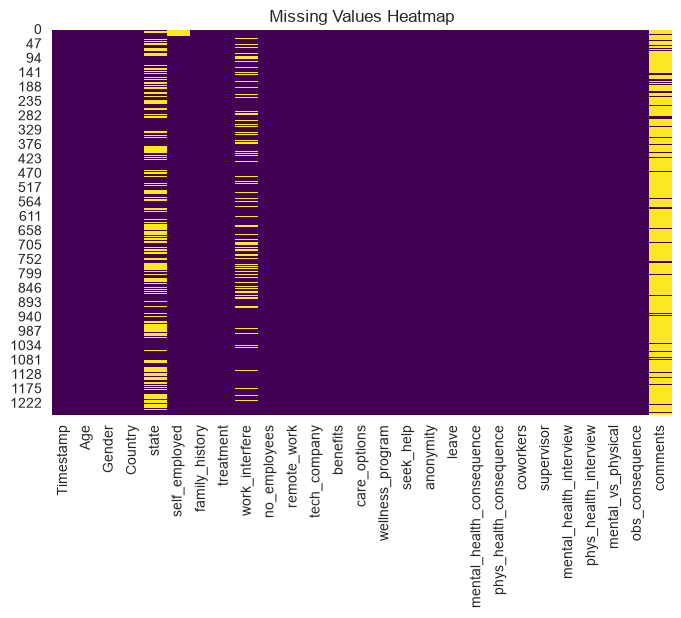

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset has 1259 rows and 27 columns with no duplicate rows. `state` (41% missing) and `comments` (87% missing) have heavy null counts and `work_interfere` has ~21% missing (likely respondents without a mental health condition). `Age` contains invalid values (negative numbers and values like 100000000000) that need cleaning. `Gender` is free text with ~49 distinct raw values that need standardizing into consistent categories.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all')

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:31:41,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

Most variables are categorical (Yes/No/Don't know or ordinal scales) capturing company policies (benefits, care_options, wellness_program, anonymity, leave) and personal factors (family_history, treatment, work_interfere). `Age` is the only numeric variable and needs cleaning. `treatment` (Yes/No) is the natural target variable for most of our comparisons.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, '->', df[col].nunique(), 'unique values')

Timestamp -> 1246 unique values
Age -> 53 unique values
Gender -> 49 unique values
Country -> 48 unique values
state -> 45 unique values
self_employed -> 2 unique values
family_history -> 2 unique values
treatment -> 2 unique values
work_interfere -> 4 unique values
no_employees -> 6 unique values
remote_work -> 2 unique values
tech_company -> 2 unique values
benefits -> 3 unique values
care_options -> 3 unique values
wellness_program -> 3 unique values
seek_help -> 3 unique values
anonymity -> 3 unique values
leave -> 5 unique values
mental_health_consequence -> 3 unique values
phys_health_consequence -> 3 unique values
coworkers -> 3 unique values
supervisor -> 3 unique values
mental_health_interview -> 3 unique values
phys_health_interview -> 3 unique values
mental_vs_physical -> 3 unique values
obs_consequence -> 2 unique values
comments -> 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Fix Age: remove impossible values, impute with median
df.loc[(df['Age'] < 18) | (df['Age'] > 75), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# 2. Standardize Gender into 3 buckets
def clean_gender(g):
    g = str(g).strip().lower()
    male_set = ['male','m','man','cis male','cis man','msle','maile','mal','make',
                'malr','mail','guy (-ish) ^_^','male-ish','male (cis)']
    female_set = ['female','f','woman','femake','cis female','cis-female/femme',
                  'female (cis)','femail','female (trans)']
    if g in male_set:
        return 'Male'
    elif g in female_set:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# 3. Handle missing values
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna("Don't know")

# 4. Drop columns that are not useful for analysis
df = df.drop(columns=['comments', 'state', 'Timestamp'])

print('Cleaned shape:', df.shape)
print('Remaining nulls:', df.isnull().sum().sum())

Cleaned shape: (1259, 24)
Remaining nulls: 0


### What all manipulations have you done and insights you found?

Age outliers (e.g. -1726, 100000000000) were capped to the median since they were clearly data-entry errors. The 49 raw Gender responses were consolidated into Male/Female/Other, revealing the sample is ~79% Male, ~20% Female, ~1% Other. `self_employed` nulls were filled with 'No' (the mode) and `work_interfere` nulls were filled with "Don't know" since they likely represent respondents without a diagnosed condition. `comments`, `state` and `Timestamp` were dropped as not useful for this analysis (too sparse or irrelevant).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

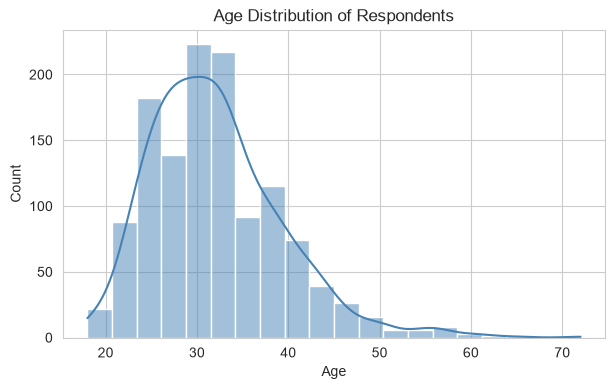

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age'); plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard choice to show the shape (spread, skew, central tendency) of a single continuous variable like Age.

##### 2. What is/are the insight(s) found from the chart?

Most respondents are between 25 and 36 years old, with a peak around age 29-31 -- a workforce skewed toward early-to-mid career tech employees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes -- knowing the dominant age band helps target mental-health programs at the career stage where most employees sit, rather than designing for a broader range than actually exists.

#### Chart - 2

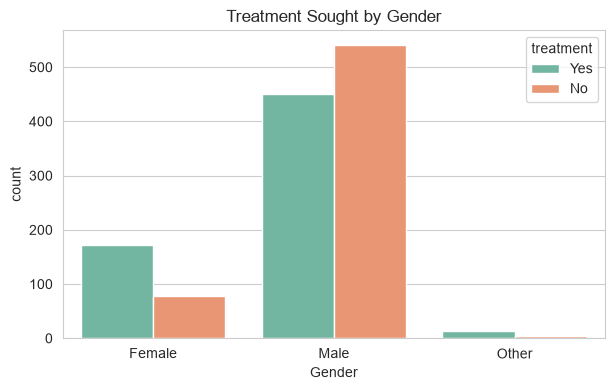

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Gender', hue='treatment', palette='Set2')
plt.title('Treatment Sought by Gender')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot directly compares treatment-seeking counts across the three gender categories.

##### 2. What is/are the insight(s) found from the chart?

Female respondents seek treatment at a much higher rate (~69%) than Male respondents (~45%), even though Male respondents dominate the sample.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes -- this suggests messaging and outreach may need to work harder to reach male employees, who are seeking help at a notably lower rate.

#### Chart - 3

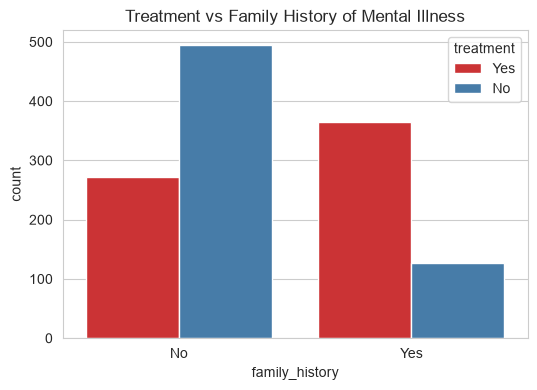

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='family_history', hue='treatment', palette='Set1')
plt.title('Treatment vs Family History of Mental Illness')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot compares the two categorical variables (family_history and treatment) directly.

##### 2. What is/are the insight(s) found from the chart?

Employees with a family history of mental illness seek treatment ~74% of the time, versus ~35% for those without -- the largest gap seen so far.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes -- family history is a strong, easily self-reported signal that employers/insurers could use (carefully and privately) to proactively surface support resources.

#### Chart - 4

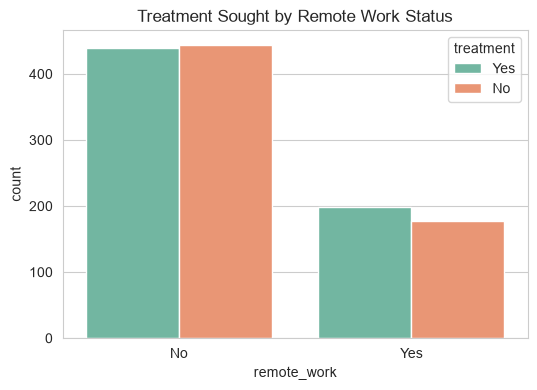

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='remote_work', hue='treatment', palette='Set2')
plt.title('Treatment Sought by Remote Work Status')
plt.show()

##### 1. Why did you pick the specific chart?

A countplot compares treatment counts across the two remote_work categories (Yes/No).

##### 2. What is/are the insight(s) found from the chart?

Remote workers seek treatment at about the same rate as office-based workers (53% vs 50%) -- remote work status shows almost no relationship with treatment-seeking.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral -- since remote work doesn't meaningfully shift treatment rates, employers don't need separate mental-health strategies for remote vs in-office staff based on this factor alone.

#### Chart - 5

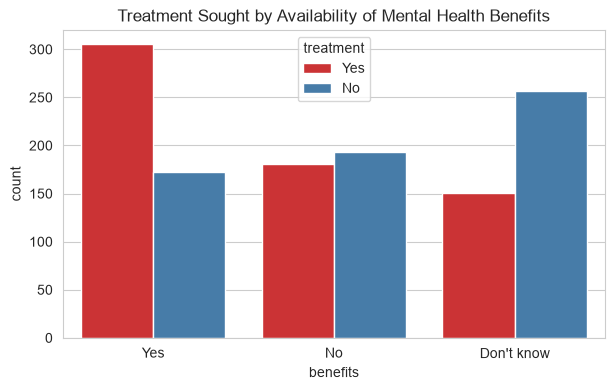

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='benefits', hue='treatment', order=['Yes',"No","Don't know"], palette='Set1')
plt.title('Treatment Sought by Availability of Mental Health Benefits')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot shows how treatment-seeking shifts across the three levels of employer-provided benefits.

##### 2. What is/are the insight(s) found from the chart?

Employees who know their company offers mental health benefits seek treatment 64% of the time, versus 48% when benefits are absent and only 37% when the employee doesn't even know if benefits exist.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, positive impact -- simply making benefits visible and well-communicated (not just offering them) appears linked to higher treatment-seeking; the 'Don't know' group is the easiest to improve with better internal communication.

#### Chart - 6

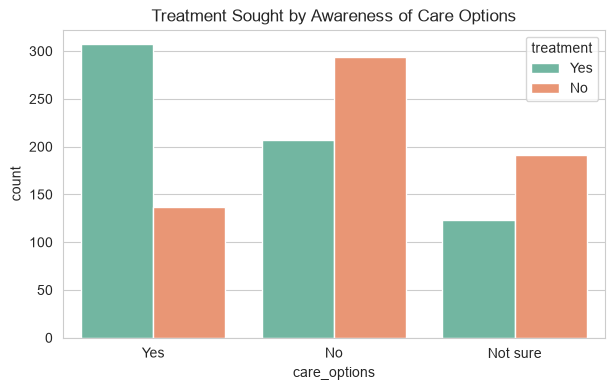

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='care_options', hue='treatment', order=['Yes','No','Not sure'], palette='Set2')
plt.title('Treatment Sought by Awareness of Care Options')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot compares treatment rates across awareness levels of available care options.

##### 2. What is/are the insight(s) found from the chart?

Employees aware of their care options seek treatment 69% of the time, the highest rate of any variable checked so far, versus ~40% for 'No' or 'Not sure'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strongly positive -- this is one of the most actionable levers: clearly documenting and communicating what care options exist could meaningfully raise treatment-seeking rates.

#### Chart - 7

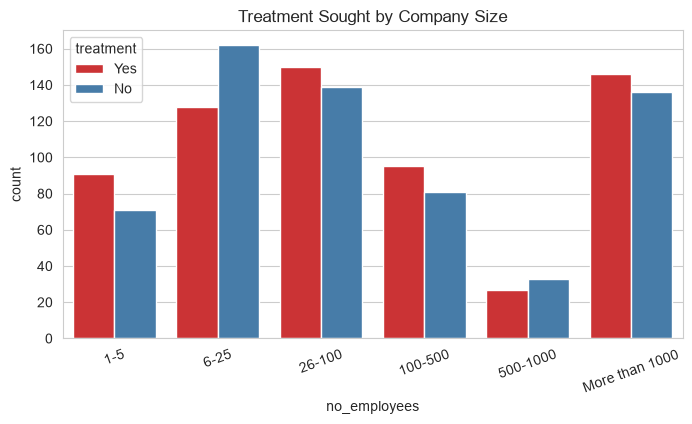

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(8,4))
order = ['1-5','6-25','26-100','100-500','500-1000','More than 1000']
sns.countplot(data=df, x='no_employees', hue='treatment', order=order, palette='Set1')
plt.title('Treatment Sought by Company Size')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

A countplot ordered by increasing company size shows whether organization scale relates to treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

Treatment rates are fairly flat across company sizes (44%-56%), with small companies (1-5 employees) slightly higher and mid-size (6-25) slightly lower -- no strong, consistent trend by size.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral -- company size alone isn't a strong lever; smaller and larger companies both need attention, so policy (benefits, care options, anonymity) matters more than headcount.

#### Chart - 8

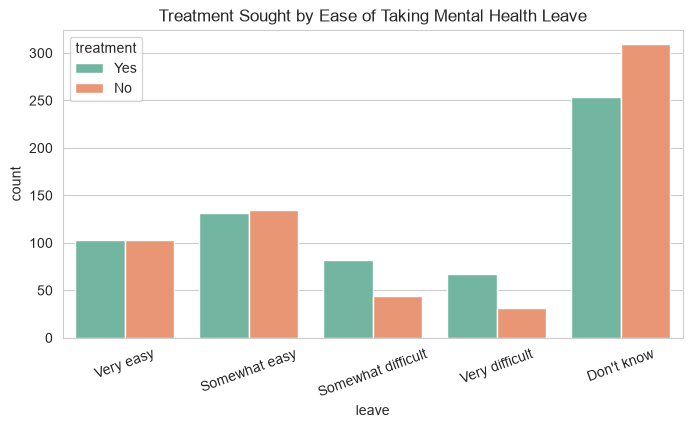

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(8,4))
order = ['Very easy','Somewhat easy','Somewhat difficult','Very difficult',"Don't know"]
sns.countplot(data=df, x='leave', hue='treatment', order=order, palette='Set2')
plt.title('Treatment Sought by Ease of Taking Mental Health Leave')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

A countplot ordered from easiest to hardest leave policy shows how perceived leave difficulty relates to treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

Counterintuitively, employees who find leave 'Very difficult' or 'Somewhat difficult' seek treatment MORE (68% and 65%) than those who find it 'Very easy' (50%) -- difficulty may reflect employees who already have a diagnosed condition and have tried to take leave.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed -- this isn't necessarily bad news operationally, but it flags that difficult leave processes coincide with employees who most need support, so simplifying leave policy could reduce a real barrier for exactly this group.

#### Chart - 9

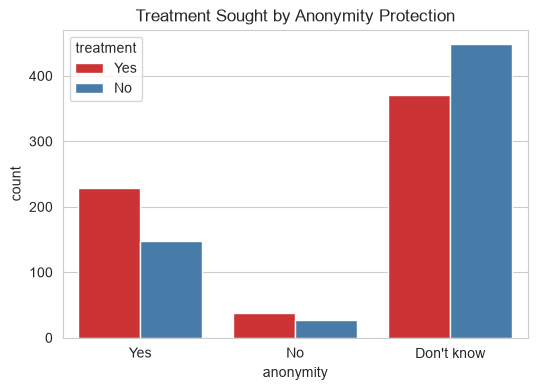

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='anonymity', hue='treatment', order=['Yes','No',"Don't know"], palette='Set1')
plt.title('Treatment Sought by Anonymity Protection')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot compares treatment rates across levels of confidence in anonymity protection.

##### 2. What is/are the insight(s) found from the chart?

Employees confident their anonymity is protected seek treatment at 61%, versus 45% for those who don't know -- anonymity assurance correlates with higher treatment-seeking.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, positive -- reinforcing and clearly communicating anonymity protections is a low-cost, high-leverage action for employers.

#### Chart - 10

C:\Users\Monalisa\AppData\Local\Temp\ipykernel_16672\589692353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='coworkers', ax=axes[0], palette='Set2', order=['Yes','Some of them','No'])
C:\Users\Monalisa\AppData\Local\Temp\ipykernel_16672\589692353.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='supervisor', ax=axes[1], palette='Set1', order=['Yes','Some of them','No'])


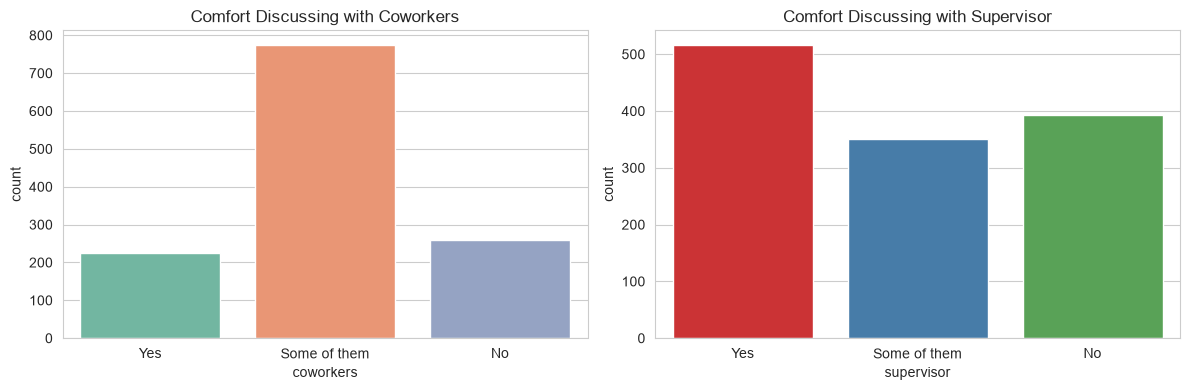

In [22]:
# Chart - 10 visualization code
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(data=df, x='coworkers', ax=axes[0], palette='Set2', order=['Yes','Some of them','No'])
axes[0].set_title('Comfort Discussing with Coworkers')
sns.countplot(data=df, x='supervisor', ax=axes[1], palette='Set1', order=['Yes','Some of them','No'])
axes[1].set_title('Comfort Discussing with Supervisor')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two side-by-side countplots let us directly compare comfort levels for two different relationships (coworkers vs supervisor) on the same scale.

##### 2. What is/are the insight(s) found from the chart?

Employees are notably less comfortable discussing mental health with supervisors (only 41% say 'Yes') than the pattern suggests for informal peer conversations ('Some of them' dominates coworker responses at 61%) -- supervisor conversations are the bigger comfort gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes -- this points to a concrete intervention: manager/supervisor training on mental health conversations, since that relationship is the weaker link in the support chain.

#### Chart - 11

C:\Users\Monalisa\AppData\Local\Temp\ipykernel_16672\2298274050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


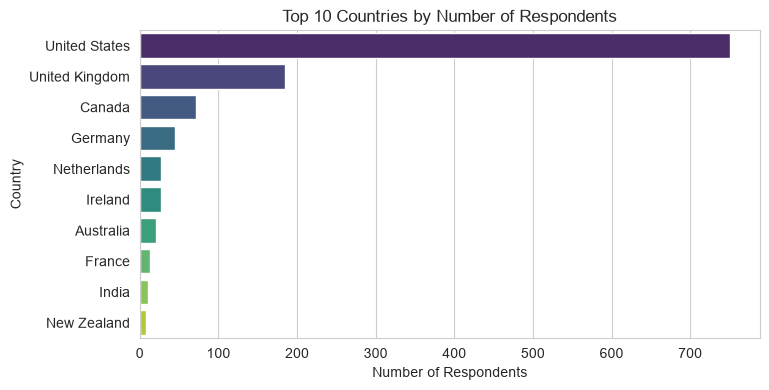

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(8,4))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is best for ranking categories (countries) by a count, especially with long country names.

##### 2. What is/are the insight(s) found from the chart?

The United States (751) and United Kingdom (185) dominate the sample by far, together making up over 74% of all respondents -- the dataset is heavily US/UK-centric.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important caveat, not a growth insight -- any geographic conclusions (including this project's) should be read as primarily describing US/UK tech culture, since other countries have too few respondents (10 or fewer) to generalize confidently.

#### Chart - 12

C:\Users\Monalisa\AppData\Local\Temp\ipykernel_16672\1444324002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='coolwarm')


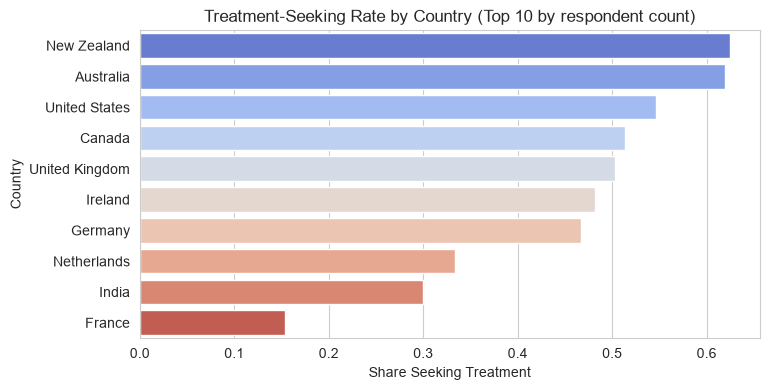

In [24]:
# Chart - 12 visualization code
top_countries = df['Country'].value_counts().head(10).index
sub = df[df['Country'].isin(top_countries)]
rate = sub.groupby('Country')['treatment'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=rate.values, y=rate.index, palette='coolwarm')
plt.title('Treatment-Seeking Rate by Country (Top 10 by respondent count)')
plt.xlabel('Share Seeking Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart of a rate (not a raw count) is the right way to compare countries fairly despite very different sample sizes.

##### 2. What is/are the insight(s) found from the chart?

Australia and New Zealand show the highest treatment rates (62%) among the top 10 countries, while France (15%) and India (30%) show the lowest -- but these smaller-sample countries should be read cautiously given the low counts seen in Chart 11.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directionally useful, but flag the caveat -- geographic differences may reflect cultural attitudes toward disclosure as much as actual need, so any global policy should be piloted locally rather than applied uniformly.

#### Chart - 13

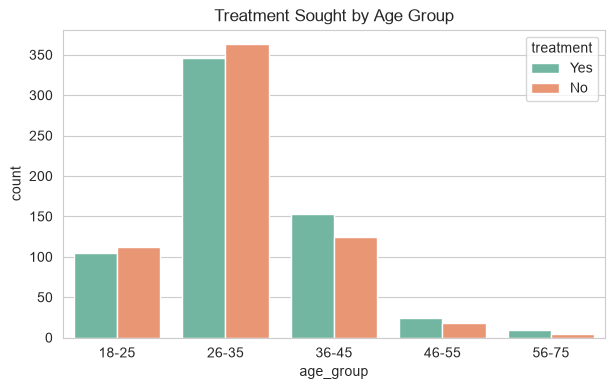

In [25]:
# Chart - 13 visualization code
df['age_group'] = pd.cut(df['Age'], bins=[17,25,35,45,55,75],
                          labels=['18-25','26-35','36-45','46-55','56-75'])
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='age_group', hue='treatment', palette='Set2')
plt.title('Treatment Sought by Age Group')
plt.show()

##### 1. Why did you pick the specific chart?

Binning the continuous Age variable into groups lets us use a countplot to compare treatment-seeking across life/career stages.

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking is fairly stable across working-age groups (roughly 48%-53%), with a slight dip in the youngest 18-25 band -- age is a weaker predictor than family_history or work_interfere.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mild negative signal for the youngest group -- outreach could be slightly more proactive for early-career employees, who may be less likely to self-identify a need for treatment.

#### Chart - 14 - Correlation Heatmap

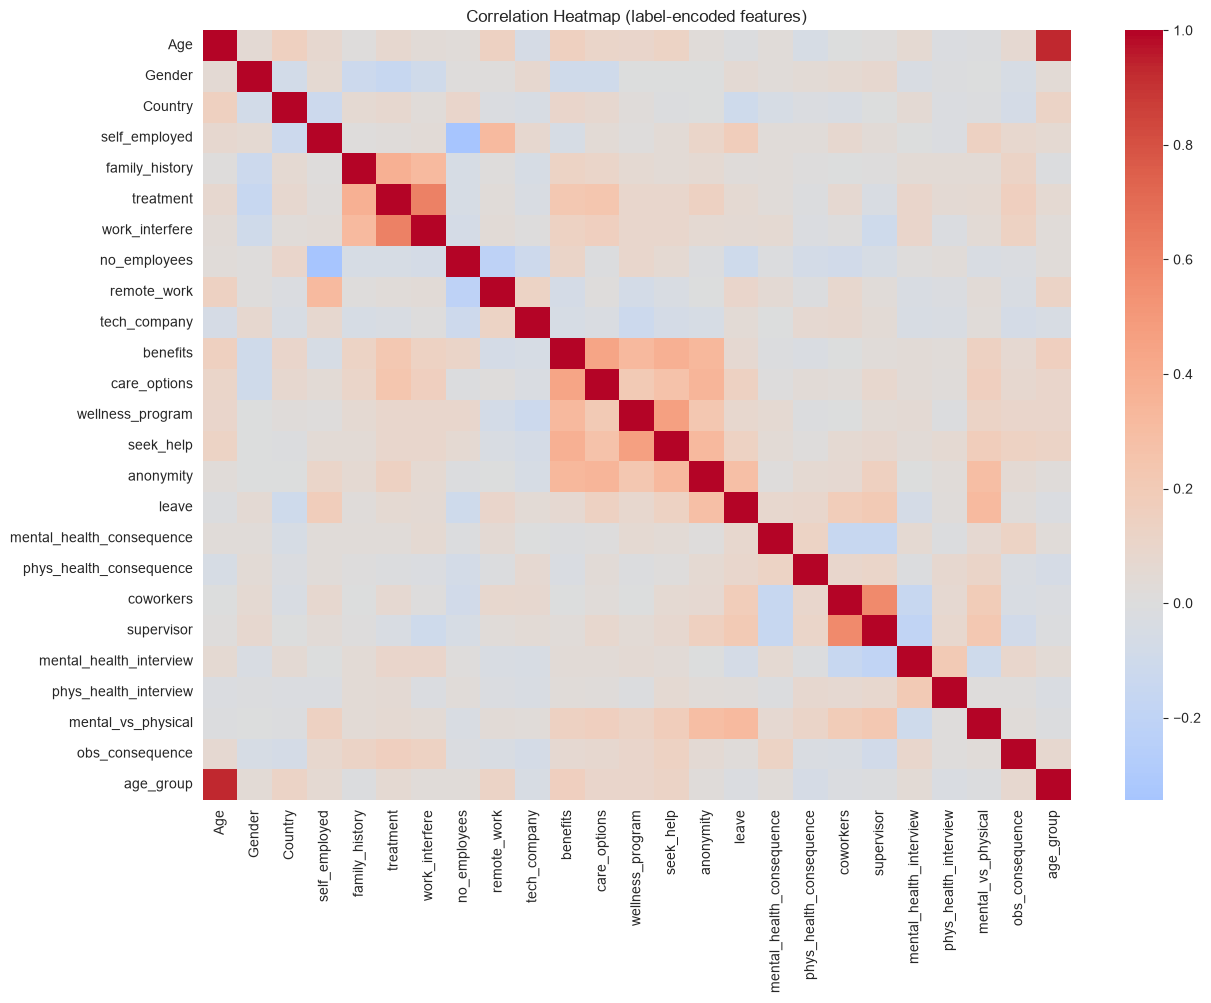

treatment                    1.000000
work_interfere               0.614879
family_history               0.377918
care_options                 0.236578
benefits                     0.226140
obs_consequence              0.156972
anonymity                    0.142889
mental_health_interview      0.098413
wellness_program             0.094713
seek_help                    0.089935
Country                      0.077681
Age                          0.073165
coworkers                    0.068433
mental_vs_physical           0.062642
leave                        0.061549
age_group                    0.059057
phys_health_interview        0.051859
mental_health_consequence    0.030221
remote_work                  0.026937
self_employed                0.020493
phys_health_consequence     -0.008933
tech_company                -0.031525
supervisor                  -0.036199
no_employees                -0.050114
Gender                      -0.154676
Name: treatment, dtype: float64

In [26]:
# Correlation Heatmap visualization code
df_enc = df.copy()
le = LabelEncoder()
for col in df_enc.columns:
    if col != 'Age':
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))

plt.figure(figsize=(14,10))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (label-encoded features)')
plt.show()

df_enc.corr()['treatment'].sort_values(ascending=False)

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to scan correlations across many variables at once after label-encoding the categorical columns.

##### 2. What is/are the insight(s) found from the chart?

`work_interfere` (r=0.61) and `family_history` (r=0.38) are by far the strongest correlates of `treatment` -- confirming they are the top predictors of treatment-seeking behavior.

#### Chart - 15 - Pair Plot

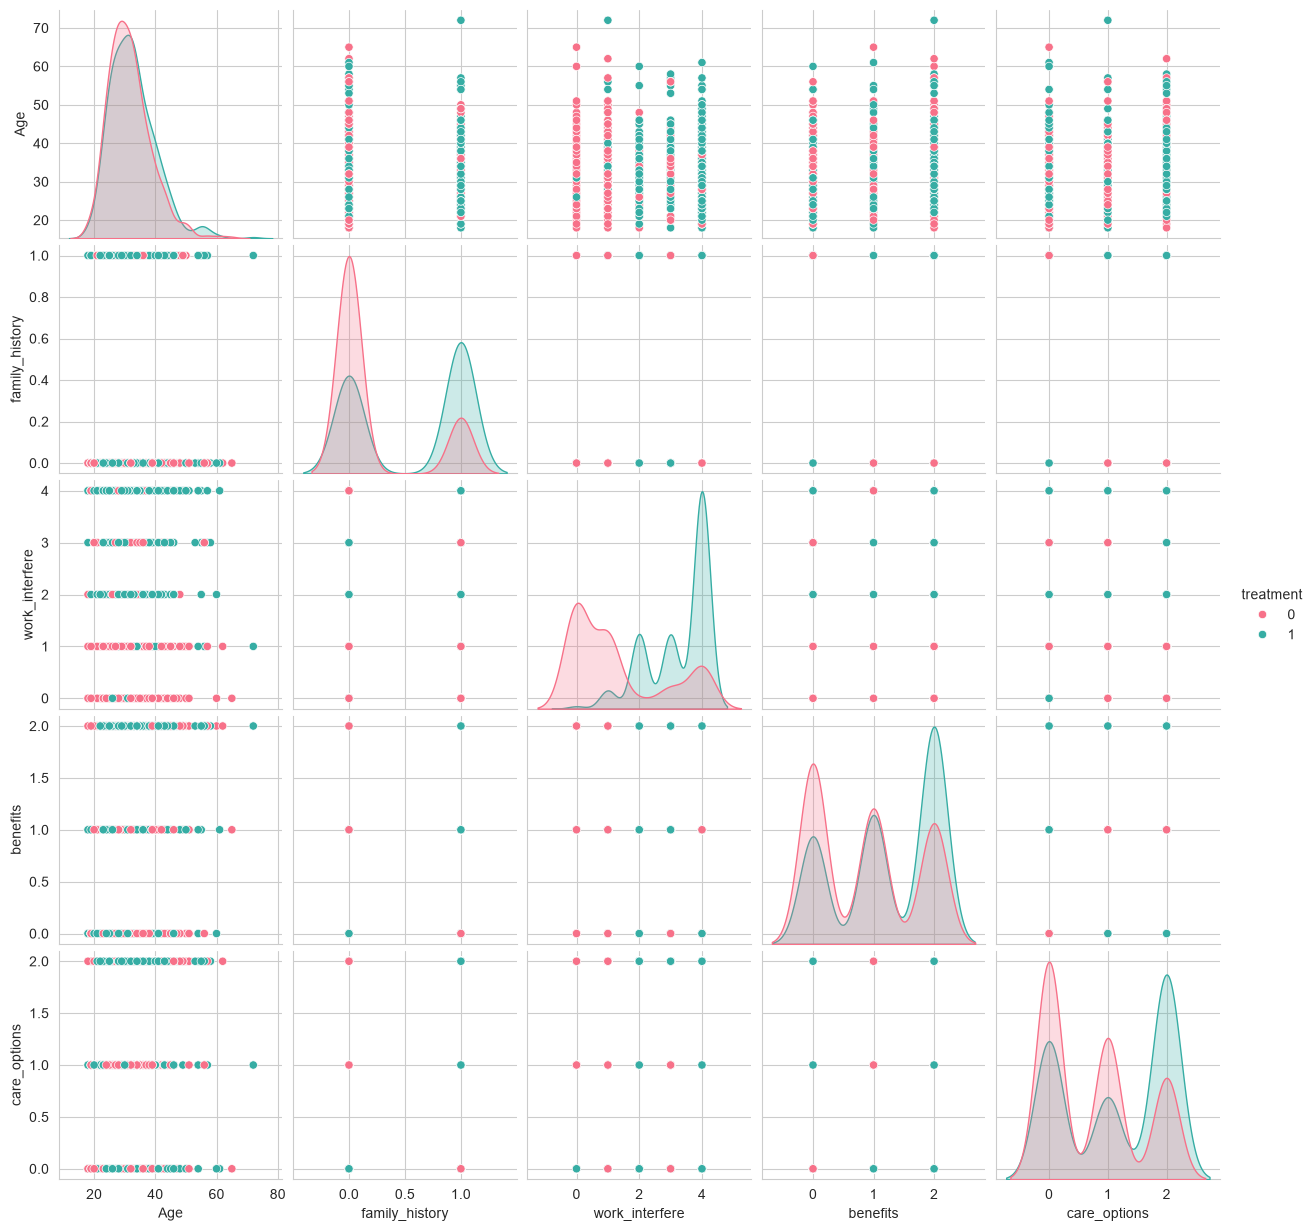

In [27]:
# Pair Plot visualization code
subset = df_enc[['Age', 'family_history', 'work_interfere', 'benefits', 'care_options', 'treatment']]
sns.pairplot(subset, hue='treatment', palette='husl', diag_kind='kde')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot lets us see pairwise relationships and separability between treatment=Yes/No across several of the strongest predictor variables at once.

##### 2. What is/are the insight(s) found from the chart?

The treatment=Yes and treatment=No groups separate most clearly along the work_interfere and family_history axes, reinforcing they carry the most signal for predicting treatment.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?

Prioritize the highest-leverage, lowest-cost levers first: (1) publicize and clarify existing mental health benefits and care options, since simply making employees aware of them raised treatment-seeking from ~40% to ~65-69% in this data; (2) reinforce anonymity guarantees for anyone seeking care; (3) train supervisors specifically on mental health conversations, since employees are far more guarded with supervisors than coworkers; (4) simplify and destigmatize the mental-health leave process, since difficulty taking leave coincides with employees who most need support; and (5) use family-history and work-interference indicators (disclosed voluntarily, with strict privacy safeguards) to proactively route at-risk employees to resources, rather than waiting for them to self-identify.

Employers should: (1) clarify and simplify leave policies for mental health, since ambiguity discourages disclosure; (2) reinforce and publicize anonymity protections for care-seeking; (3) train supervisors specifically, since comfort discussing issues with supervisors lags coworkers; (4) target awareness campaigns at male employees and at companies with fewer benefits/care_options, where treatment rates are lowest; and (5) use family-history and work-interference signals (with employee consent and privacy safeguards) to proactively route people to resources.

# **Conclusion**

Family history of mental illness and self-reported work interference are the strongest predictors of whether a tech employee seeks treatment. Female respondents seek treatment at notably higher rates than male respondents. Company-provided benefits, care options and anonymity protections show a positive but moderate relationship with treatment-seeking, suggesting workplace policy does matter, just less than personal/clinical factors. These findings point toward both individual-level (destigmatization, family-history-aware outreach) and policy-level (clearer leave/anonymity policies) interventions.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***